# Project 2 - Classification - K-Nearest Neighbors (KNN)

**In this file:** 
+ Data Preparation + Modeling - K-Nearest Neighbors (KNN)

=== 

**On other files:**
+ Business Understanding + Data Undertanding + Evaluation (of analyzed models).  *File Name:* ML_02_Business.ipynb 
+ Model Decision Trees.  *File Name:* ML_02_Model_DecisionTrees.ipynb
+ Model K-Nearest Neighbor (KNN).  *File Name:* ML_Model_KNN.ipynb
+ Model Logistic Regression.  *File Name:* ML_02_Model_LogisticR.ipynb
+ Models: Support Vector Machine (SVM), Neural networks and Naïve Bayes.  *File Name:* ML_02_Model_SVN_NN_NB.ipynb


===

#### **Group V**
+ Ana Isabel Moura, 20250168
+ Ayoub Mask, 20250183
+ Beatriz Lobão, 20250566
+ Joao Bernardino, 20250922
+ Lara Pereira, 20250921

In [1]:
#Load Packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

RANDOM_STATE = 42
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


## Data Preparation 

In [2]:
df = pd.read_excel('/Users/anamoura/Desktop/MachineLearning/Project_02/campaign.xlsx')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Loaded: 2,240 rows x 29 columns


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635.0,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11.0,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426.0,...,4,0,0,0,0,0,0,3,11,0


In [3]:
#Create a data copy 
df_prep = df.copy()

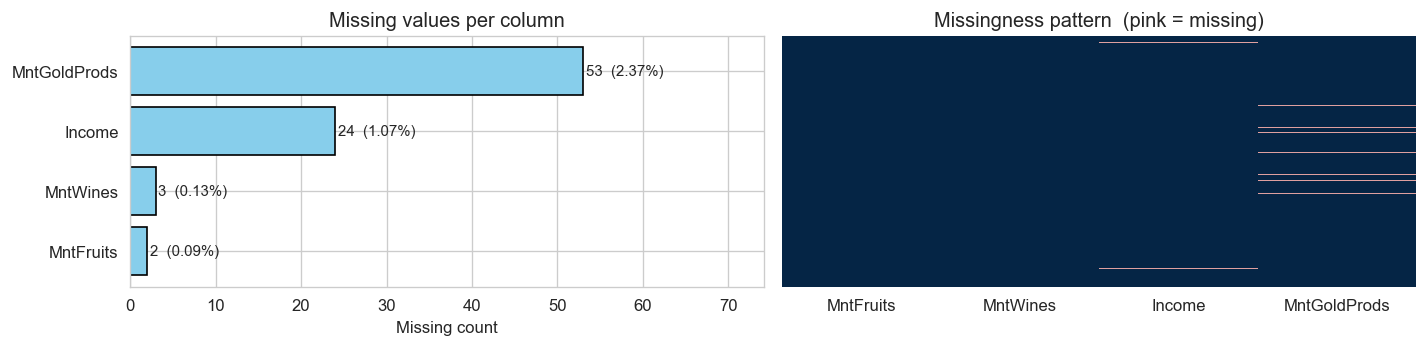

In [4]:
#Check Missing Values 

missing = df_prep.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
pct = (missing / len(df_prep) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
bars = axes[0].barh(missing.index, missing.values, color='skyblue', edgecolor='black')
for bar, cnt, p in zip(bars, missing.values, pct.values):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{cnt}  ({p}%)', va='center', fontsize=9)
axes[0].set_xlabel('Missing count')
axes[0].set_title('Missing values per column')
axes[0].set_xlim(0, missing.max() * 1.4)
sns.heatmap(df_prep[missing.index.tolist()].isnull(), cbar=False, yticklabels=False,
            cmap=["#052545", "#dfa0a0"], ax=axes[1])
axes[1].set_title('Missingness pattern  (pink = missing)')
plt.tight_layout()
plt.show()

In [5]:
#Drop Zero Variance and ID Columns

print('Unique values — Z columns:')
print(df_prep[['Z_CostContact', 'Z_Revenue']].nunique())
df_prep.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'], inplace=True)
print(f'Shape after drop: {df_prep.shape}')

Unique values — Z columns:
Z_CostContact    1
Z_Revenue        1
dtype: int64
Shape after drop: (2240, 26)


In [6]:
#Remore Erro Rows 

n_before = len(df_prep)
df_prep['Dt_Customer'] = pd.to_datetime(df_prep['Dt_Customer'], errors='coerce', dayfirst=False) 
df_prep = df_prep.dropna(subset=['Dt_Customer']).copy()
df_prep = df_prep[df_prep['MntSweetProducts'] <= 1000].copy()
df_prep = df_prep[df_prep['Year_Birth'] >= 1930].copy()
df_prep = df_prep[df_prep['Dt_Customer'].dt.year <= 2015].copy()
df_prep = df_prep.reset_index(drop=True)
print(f'Rows removed: {n_before - len(df_prep)}  -  Clean dataset: {len(df_prep):,} rows')

Rows removed: 8  -  Clean dataset: 2,232 rows


In [7]:
#Fix negatives 
df_prep['MntFishProducts'] = df_prep['MntFishProducts'].clip(lower=0)

#Cap Income outliers
income_99 = df_prep['Income'].quantile(0.99)
df_prep['Income'] = df_prep['Income'].clip(upper=income_99)
print(f'Income capped at 99th pct: {income_99:,.0f}')

Income capped at 99th pct: 94,466


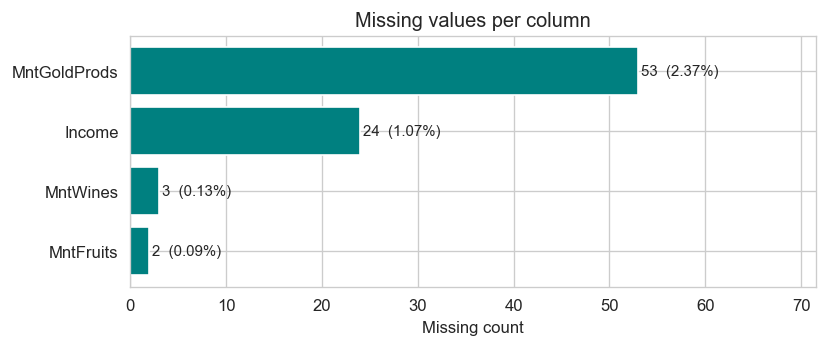

In [8]:
#Check Missing Values 

missing = df_prep.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
pct = (missing / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(missing.index, missing.values, color='teal')

for bar, count, p in zip(bars, missing.values, pct.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{count}  ({p}%)', va='center', fontsize=9)

ax.set_xlabel('Missing count')
ax.set_title('Missing values per column')
ax.set_xlim(0, missing.max() * 1.35)
plt.tight_layout()
plt.show()

In [9]:
#Handle Missing Values 

print('Missing before imputation:')
print(df_prep.isnull().sum()[df_prep.isnull().sum() > 0])

imputation_medians = {}
for col in ['Income', 'MntWines', 'MntFruits', 'MntGoldProds']:
    med = df_prep[col].median()
    imputation_medians[col] = med
    df_prep[col] = df_prep[col].fillna(med)
    print(f'  {col}: imputed with median = {med:.1f}')

print(f'\nTotal missing after imputation: {df_prep.isnull().sum().sum()}')

Missing before imputation:
Income          24
MntWines         3
MntFruits        2
MntGoldProds    53
dtype: int64
  Income: imputed with median = 51369.0
  MntWines: imputed with median = 174.0
  MntFruits: imputed with median = 8.0
  MntGoldProds: imputed with median = 25.0

Total missing after imputation: 0


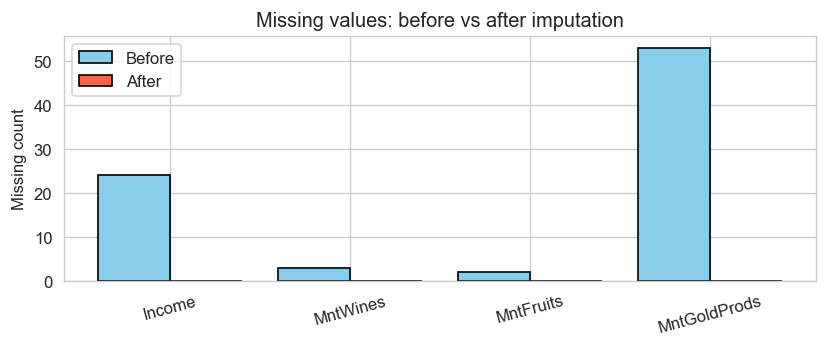

In [10]:
# Before vs after visualisation
before_counts = {'Income': 24, 'MntWines': 3, 'MntFruits': 2, 'MntGoldProds': 53}
x = np.arange(len(before_counts))
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(x - 0.2, before_counts.values(), 0.4, label='Before', color='skyblue', edgecolor='black')
ax.bar(x + 0.2, [0]*4, 0.4, label='After', color='tomato', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(before_counts.keys(), rotation=15)
ax.set_ylabel('Missing count')
ax.set_title('Missing values: before vs after imputation')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
#Feature Engeneering 

#Reference Date and Year to Age 
REFERENCE_YEAR = 2014
REFERENCE_DATE = pd.Timestamp('2014-06-29')

df_prep['Age']                  = REFERENCE_YEAR - df_prep['Year_Birth']
df_prep['Customer_Tenure_Days'] = (REFERENCE_DATE - df_prep['Dt_Customer']).dt.days

#Spending Mix to Total Spent
spend_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
purchase_cols = ['NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumStorePurchases']

#Accepted mix to Total Accepted 
accepted_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']

df_prep['TotalSpent'] = df_prep[spend_cols].sum(axis=1)
df_prep['TotalPurchases'] = df_prep[purchase_cols].sum(axis=1)
df_prep['TotalAccepted'] = df_prep[accepted_cols].sum(axis=1)
df_prep['HasChildren'] = ((df_prep['Kidhome'] + df_prep['Teenhome']) > 0).astype(int) #Children Mix to Yes or No Children

df_prep.drop(columns=['Year_Birth', 'Dt_Customer'], inplace=True) #Drop Year of birth and dt customer for better prediction 
print(f'Shape after feature engineering: {df_prep.shape}')

Shape after feature engineering: (2232, 30)


In [12]:
#Encoding Categorical Variables 

marital_map = {'Married':'Partner','Together':'Partner','Single':'Single',
               'Divorced':'Divorced','Widow':'Widow',
               'Alone':'Single','Absurd':'Single','YOLO':'Single'}
df_prep['Marital_Status'] = df_prep['Marital_Status'].map(marital_map) #Reduce categories of maritial status

edu_order = {'Basic':0,'2n Cycle':1,'Graduation':2,'Master':3,'PhD':4} #Enconde Education to Numbers 
df_prep['Education'] = df_prep['Education'].map(edu_order)

df_prep = pd.get_dummies(df_prep, columns=['Marital_Status'], drop_first=True) #Create dummies 
print(f'Shape after encoding: {df_prep.shape}')

Shape after encoding: (2232, 32)


## Train and Test Split

In [13]:
TARGET = 'Response'
X = df_prep.drop(columns=[TARGET])
y = df_prep[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y #80/20
)

print(f'Train: {X_train.shape[0]:,} rows  | Positives: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test : {X_test.shape[0]:,} rows  | Positives: {y_test.sum()} ({y_test.mean()*100:.1f}%)')
print(f'Features: {X_train.shape[1]}')

Train: 1,785 rows  | Positives: 266 (14.9%)
Test : 447 rows  | Positives: 66 (14.8%)
Features: 31


## Modeling

k= 11  No scaling: 0.6859  |  Scaled: 0.8310  |  Gain: +0.1451
k= 21  No scaling: 0.6926  |  Scaled: 0.8552  |  Gain: +0.1626
k= 51  No scaling: 0.6607  |  Scaled: 0.8715  |  Gain: +0.2107


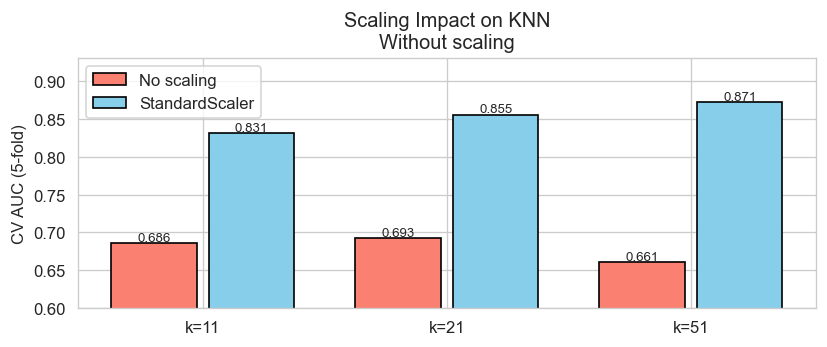

In [14]:
#Comparation between Scaling and NOT Scaling 

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

k_test  = [11, 21, 51]
raw_aucs, scaled_aucs = [], []

for k in k_test:
    #Without scaling
    auc_raw = cross_val_score(
        KNeighborsClassifier(n_neighbors=k), X_train, y_train,
        cv=cv, scoring='roc_auc'
    ).mean()
    raw_aucs.append(auc_raw)

    #With scaling inside the Pipeline
    pipe_sc = Pipeline([('scaler', StandardScaler()),
                        ('knn', KNeighborsClassifier(n_neighbors=k))])
    auc_sc = cross_val_score(pipe_sc, X_train, y_train,
                             cv=cv, scoring='roc_auc').mean()
    scaled_aucs.append(auc_sc)

    print(f'k={k:3d}  No scaling: {auc_raw:.4f}  |  Scaled: {auc_sc:.4f}  |  Gain: +{auc_sc - auc_raw:.4f}')

x = np.arange(len(k_test))
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(x - 0.2, raw_aucs,    0.35, label='No scaling', color='salmon',    edgecolor='black')
ax.bar(x + 0.2, scaled_aucs, 0.35, label='StandardScaler', color='skyblue', edgecolor='black')
for i, (ns, sc) in enumerate(zip(raw_aucs, scaled_aucs)):
    ax.text(i - 0.2, ns + 0.003, f'{ns:.3f}', ha='center', fontsize=8)
    ax.text(i + 0.2, sc + 0.003, f'{sc:.3f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f'k={k}' for k in k_test])
ax.set_ylim(0.60, 0.93)
ax.set_ylabel('CV AUC (5-fold)')
ax.set_title('Scaling Impact on KNN\nWithout scaling')
ax.legend()
plt.tight_layout()
plt.show()

### Bias variance - K Selection 

In [15]:
k_values  = [1, 2, 3, 5, 7, 8, 12, 15, 21, 25, 33, 40, 42, 47, 50, 53, 62, 68, 70, 73, 85, 87, 90, 95, 97, 100, 103, 150, 180, 200, 250, 300]
train_aucs, cv_means, cv_stds = [], [], []

print(f'{"K":>5}  {"Train AUC":>10}  {"CV AUC":>10}  {"Std":>8}  {"Gap":>8}  Status')
print('-' * 72)

for k in k_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn',    KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='euclidean'))
    ])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    pipe.fit(X_train, y_train)
    tr_auc = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])

    train_aucs.append(tr_auc)
    cv_means.append(cv_scores.mean())
    cv_stds.append(cv_scores.std())

    gap = tr_auc - cv_scores.mean()
    if gap > 0.15:
        flag = 'overfit'
    elif cv_scores.mean() < 0.80 and k <= 5:
        flag = 'borderline overfit'
    elif cv_scores.mean() < 0.86 and k >= 71:
        flag = 'underfit'
    else:
        flag = 'good zone'

    print(f'{k:>5}  {tr_auc:>10.4f}  {cv_scores.mean():>10.4f}  '
          f'{cv_scores.std():>8.4f}  {gap:>8.4f}  {flag}')

    K   Train AUC      CV AUC       Std       Gap  Status
------------------------------------------------------------------------
    1      0.9864      0.6901    0.0173    0.2963  overfit
    2      0.9771      0.7317    0.0178    0.2455  overfit
    3      0.9621      0.7531    0.0222    0.2090  overfit
    5      0.9391      0.7924    0.0219    0.1467  borderline overfit
    7      0.9282      0.8144    0.0144    0.1138  good zone
    8      0.9235      0.8203    0.0115    0.1032  good zone
   12      0.9137      0.8353    0.0233    0.0784  good zone
   15      0.9056      0.8448    0.0188    0.0608  good zone
   21      0.9013      0.8552    0.0153    0.0460  good zone
   25      0.8934      0.8567    0.0156    0.0366  good zone
   33      0.8894      0.8698    0.0137    0.0196  good zone
   40      0.8930      0.8702    0.0156    0.0228  good zone
   42      0.8933      0.8717    0.0133    0.0216  good zone
   47      0.8938      0.8719    0.0125    0.0219  good zone
   50      0

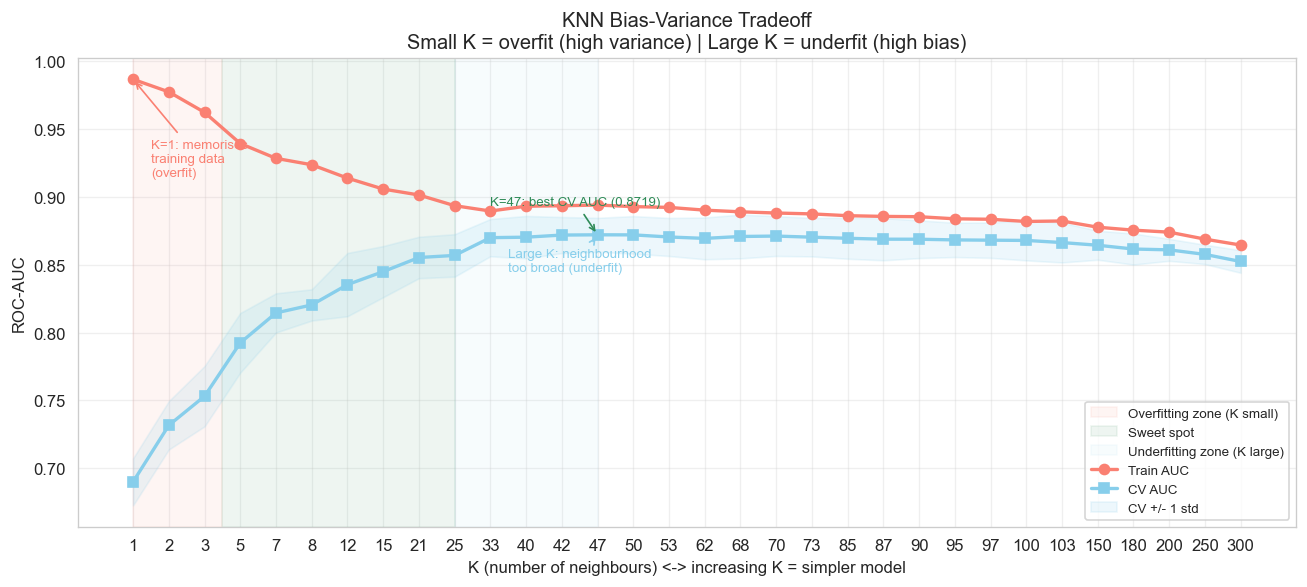

In [16]:
#Visualize Results 

x_pos = list(range(len(k_values)))
x_labels = [str(k) for k in k_values]

fig, ax = plt.subplots(figsize=(11, 5))

#Shade zones
ax.axvspan(0,    2.5, alpha=0.08, color='salmon', label='Overfitting zone (K small)')
ax.axvspan(2.5,  9,   alpha=0.08, color='seagreen', label='Sweet spot')
ax.axvspan(9,   13,   alpha=0.06, color='skyblue', label='Underfitting zone (K large)')

ax.plot(x_pos, train_aucs, 'o-', color='salmon',    lw=2, ms=6, label='Train AUC')
ax.plot(x_pos, cv_means,   's-', color='skyblue', lw=2, ms=6, label='CV AUC')
ax.fill_between(x_pos,
                [m - s for m, s in zip(cv_means, cv_stds)],
                [m + s for m, s in zip(cv_means, cv_stds)],
                alpha=0.15, color='skyblue', label='CV +/- 1 std')

#Annotations
ax.annotate('K=1: memorises\ntraining data\n(overfit)',
            xy=(0, train_aucs[0]), xytext=(0.5, 0.915),
            arrowprops=dict(arrowstyle='->', color='salmon'),
            fontsize=8, color='salmon')

best_cv_idx = int(np.argmax(cv_means))
ax.annotate(f'K={k_values[best_cv_idx]}: best CV AUC ({cv_means[best_cv_idx]:.4f})',
            xy=(best_cv_idx, cv_means[best_cv_idx]),
            xytext=(best_cv_idx - 3, cv_means[best_cv_idx] + 0.022),
            arrowprops=dict(arrowstyle='->', color='seagreen'),
            fontsize=8, color='seagreen')

ax.annotate('Large K: neighbourhood\ntoo broad (underfit)',
            xy=(13, cv_means[13]), xytext=(10.5, 0.845),
            arrowprops=dict(arrowstyle='->', color='skyblue'),
            fontsize=8, color='skyblue')

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('K (number of neighbours) <-> increasing K = simpler model')
ax.set_ylabel('ROC-AUC')
ax.set_title('KNN Bias-Variance Tradeoff\n'
             'Small K = overfit (high variance) | Large K = underfit (high bias)')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
#Hyperparameter Tuning 

param_grid = {
    'knn__n_neighbors': [1, 2, 3, 5, 7, 8, 12, 15, 21, 25, 33, 40, 42, 47, 50, 53, 62, 68, 70, 73, 85, 87, 90, 95, 97, 100, 103, 150, 180, 200, 250, 300],
    'knn__weights'    : ['uniform', 'distance'],
    'knn__metric'     : ['euclidean', 'manhattan', 'cosine', 'minkowski'],
}

pipe_gs = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

grid_search = GridSearchCV(
    pipe_gs, param_grid,
    cv=cv, scoring='roc_auc', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f'Best hyperparameters : {grid_search.best_params_}')
print(f'Best CV AUC          : {grid_search.best_score_:.4f}')

Best hyperparameters : {'knn__metric': 'manhattan', 'knn__n_neighbors': 73, 'knn__weights': 'uniform'}
Best CV AUC          : 0.8741


In [18]:
#Train final model 

best_pipe   = grid_search.best_estimator_
best_k      = grid_search.best_params_['knn__n_neighbors']
best_weight = grid_search.best_params_['knn__weights']
best_metric = grid_search.best_params_['knn__metric']

best_pipe.fit(X_train, y_train)
print('Final pipeline trained.')
print(f'  K (neighbours)     : {best_k}')
print(f'  Weighting scheme   : {best_weight}')
print(f'  Distance metric    : {best_metric}')
print(f'  Scaler             : StandardScaler (fit on training data only)')
print(f'  Imbalance handling : threshold tuning (KNN has no class_weight)')

Final pipeline trained.
  K (neighbours)     : 73
  Weighting scheme   : uniform
  Distance metric    : manhattan
  Scaler             : StandardScaler (fit on training data only)
  Imbalance handling : threshold tuning (KNN has no class_weight)


## Evaluation 

In [19]:
#Predictions on test split 

y_pred       = best_pipe.predict(X_test)
y_pred_proba = best_pipe.predict_proba(X_test)[:, 1]

### Metrics Evaluation and Confusion Matrix

In [20]:
#Metrics analysis 

print('=' * 56)
print('  METRICS  (default threshold = 0.5)')
print('=' * 56)
print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred):.4f}  - very low: threshold too high')
print(f'  F1-Score  : {f1_score(y_test, y_pred):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_pred_proba):.4f}  - threshold-independent')
print()
print(classification_report(y_test, y_pred, target_names=['No Response (0)', 'Response (1)']))

  METRICS  (default threshold = 0.5)
  Accuracy  : 0.8613
  Precision : 0.8333
  Recall    : 0.0758  - very low: threshold too high
  F1-Score  : 0.1389
  ROC-AUC   : 0.8641  - threshold-independent

                 precision    recall  f1-score   support

No Response (0)       0.86      1.00      0.92       381
   Response (1)       0.83      0.08      0.14        66

       accuracy                           0.86       447
      macro avg       0.85      0.54      0.53       447
   weighted avg       0.86      0.86      0.81       447



Observations: 
+ AUC is good but Recall is low.
+ The model ranks customers correctly but 0.5 threshold isn't correct here.

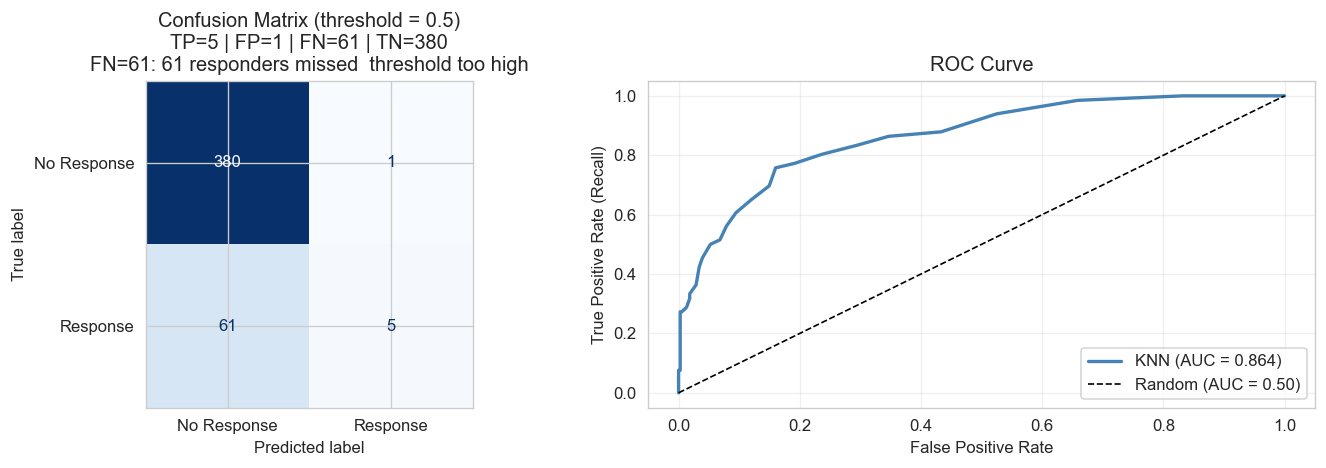

AUC = 0.8641  -  Good


In [21]:
#Confusion Matrix 
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['No Response', 'Response']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(
    f'Confusion Matrix (threshold = 0.5)\n'
    f'TP={tp} | FP={fp} | FN={fn} | TN={tn}\n'
    f'FN={fn}: {fn} responders missed  threshold too high'
)

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'KNN (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

auc_label = ('Excellent' if auc >= 0.9 else 'Good' if auc >= 0.8
             else 'Satisfactory' if auc >= 0.7 else 'Poor')
print(f'AUC = {auc:.4f}  -  {auc_label}')

In [22]:
#Overfitting Check 

train_auc_final = roc_auc_score(y_train, best_pipe.predict_proba(X_train)[:, 1])
cv_auc_scores   = cross_val_score(best_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
cv_auc_final    = cv_auc_scores.mean()
test_auc_final  = roc_auc_score(y_test, y_pred_proba)

#K=1 reference for comparison
pipe_k1 = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=1))])
pipe_k1.fit(X_train, y_train)
tr_k1 = roc_auc_score(y_train, pipe_k1.predict_proba(X_train)[:, 1])
cv_k1 = cross_val_score(pipe_k1, X_train, y_train, cv=cv, scoring='roc_auc').mean()

print('=== Overfitting Check ===')
print(f'  Train AUC           : {train_auc_final:.4f}')
print(f'  CV AUC (5-fold)     : {cv_auc_final:.4f}  +/- {cv_auc_scores.std():.4f}')
print(f'  Test AUC            : {test_auc_final:.4f}')
print(f'  Train-CV gap        : {train_auc_final - cv_auc_final:.4f}  (target < 0.05)')
print(f'  CV-Test gap         : {abs(cv_auc_final - test_auc_final):.4f}  (target < 0.05)')
print(f'\n  For comparison K=1  : Train={tr_k1:.4f}  CV={cv_k1:.4f}  Gap={tr_k1-cv_k1:.4f}  - textbook overfit')

gap = train_auc_final - cv_auc_final
verdict = ('Excellent: no overfitting' if gap < 0.03
           else 'Good: no meaningful overfitting' if gap < 0.05
           else 'Mild overfitting: acceptable' if gap < 0.10
           else 'Overfitting: increase K')
print(f'\n  Verdict: {verdict}')


=== Overfitting Check ===
  Train AUC           : 0.8880
  CV AUC (5-fold)     : 0.8742  +/- 0.0151
  Test AUC            : 0.8641
  Train-CV gap        : 0.0138  (target < 0.05)
  CV-Test gap         : 0.0101  (target < 0.05)

  For comparison K=1  : Train=0.9864  CV=0.6901  Gap=0.2963  - textbook overfit

  Verdict: Excellent: no overfitting


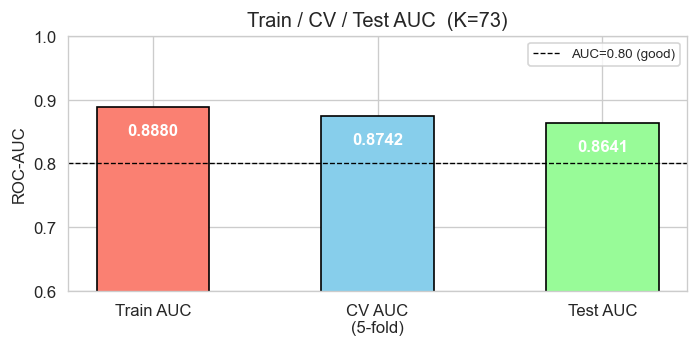

In [23]:
#Vizualize Overfiting 

fig, ax = plt.subplots(figsize=(6, 3))
labels = ['Train AUC', 'CV AUC\n(5-fold)', 'Test AUC']
values = [train_auc_final, cv_auc_final, test_auc_final]
colors = ['salmon', 'skyblue', 'palegreen']
bars = ax.bar(labels, values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val - 0.025,
            f'{val:.4f}', ha='center', va='top', fontsize=10, fontweight='bold', color='white')
ax.set_ylim(0.60, 1.0)
ax.set_ylabel('ROC-AUC')
ax.set_title(f'Train / CV / Test AUC  (K={best_k})')
ax.axhline(0.80, color='black', ls='--', lw=0.8, label='AUC=0.80 (good)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

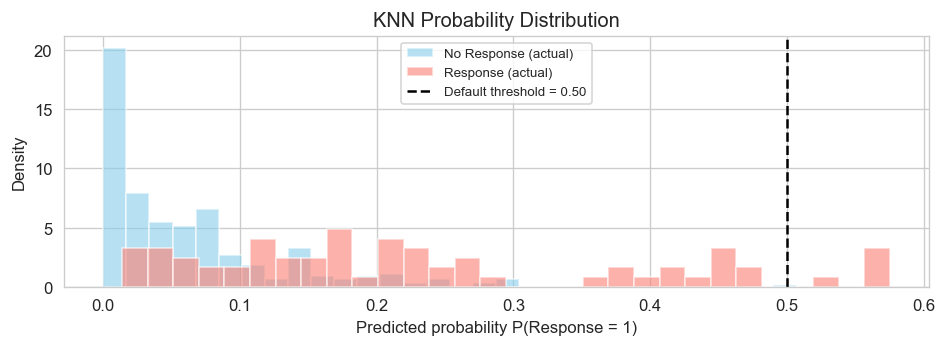

In [24]:
#Threshold Optimization 

# Show why 0.5 fails: probability distribution
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(y_pred_proba[y_test == 0], bins=30, alpha=0.6,
        color='skyblue', label='No Response (actual)', density=True)
ax.hist(y_pred_proba[y_test == 1], bins=30, alpha=0.6,
        color='salmon', label='Response (actual)', density=True)
ax.axvline(0.5, color='black', ls='--', lw=1.5, label='Default threshold = 0.50')
ax.set_xlabel('Predicted probability P(Response = 1)')
ax.set_ylabel('Density')
ax.set_title('KNN Probability Distribution')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

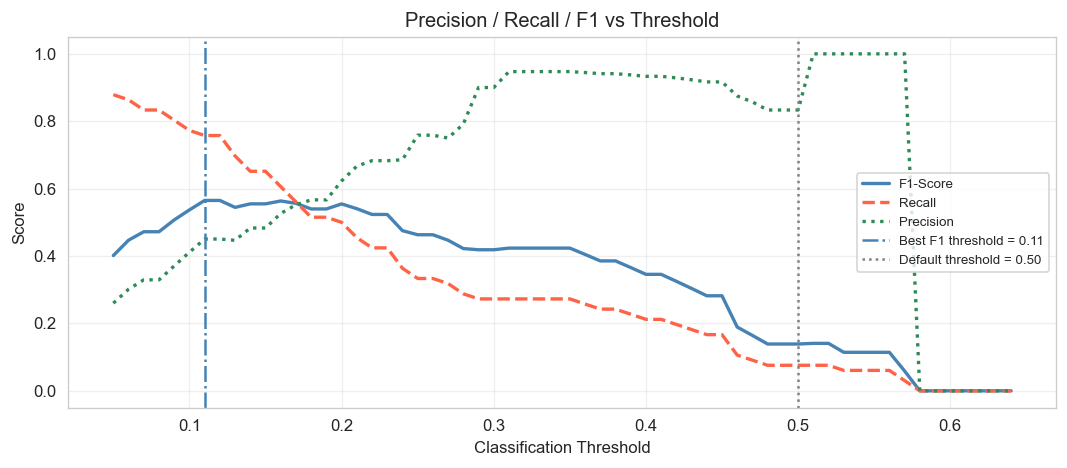

Optimal threshold (max F1): 0.11
  F1        at optimal: 0.5650
  Recall    at optimal: 0.7576
  Precision at optimal: 0.4505


In [25]:
#Check Threshold range 

thresholds_range = np.arange(0.05, 0.65, 0.01)
f1_list, recall_list, precision_list = [], [], []

for t in thresholds_range:
    y_t = (y_pred_proba >= t).astype(int)
    f1_list.append(f1_score(y_test, y_t, zero_division=0))
    recall_list.append(recall_score(y_test, y_t, zero_division=0))
    precision_list.append(precision_score(y_test, y_t, zero_division=0))

best_f1_idx   = int(np.argmax(f1_list))
opt_threshold = thresholds_range[best_f1_idx]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds_range, f1_list,        lw=2, color='steelblue', label='F1-Score')
ax.plot(thresholds_range, recall_list,    lw=2, color='tomato',    ls='--', label='Recall')
ax.plot(thresholds_range, precision_list, lw=2, color='seagreen',  ls=':',  label='Precision')
ax.axvline(opt_threshold, color='steelblue', ls='-.',
           label=f'Best F1 threshold = {opt_threshold:.2f}')
ax.axvline(0.5, color='gray', ls=':', label='Default threshold = 0.50')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold')
ax.legend(loc='center right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Optimal threshold (max F1): {opt_threshold:.2f}')
print(f'  F1        at optimal: {f1_list[best_f1_idx]:.4f}')
print(f'  Recall    at optimal: {recall_list[best_f1_idx]:.4f}')
print(f'  Precision at optimal: {precision_list[best_f1_idx]:.4f}')

=== Metrics at optimal threshold (0.11) ===
  Accuracy  : 0.8277
  Precision : 0.4505
  Recall    : 0.7576
  F1-Score  : 0.5650



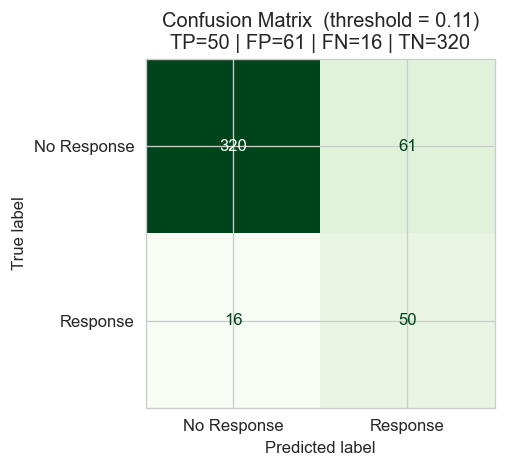

In [26]:
#Confusion Matrix
y_pred_opt = (y_pred_proba >= opt_threshold).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()

print(f'=== Metrics at optimal threshold ({opt_threshold:.2f}) ===')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_opt):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_opt):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_opt):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_opt):.4f}')
print()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_opt, display_labels=['No Response', 'Response']).plot(
    ax=ax, colorbar=False, cmap='Greens')
ax.set_title(f'Confusion Matrix  (threshold = {opt_threshold:.2f})\n'
             f'TP={tp_o} | FP={fp_o} | FN={fn_o} | TN={tn_o}')
plt.tight_layout()
plt.show()

### Gains and Lift

In [27]:
#Check Rank order 

rank_df = pd.DataFrame({'y_true': y_test.values, 'y_score': y_pred_proba})
rank_df = rank_df.sort_values('y_score', ascending=False).reset_index(drop=True)

n_total, n_pos = len(rank_df), int(rank_df['y_true'].sum())
dec_size = n_total // 10
rows, cum_pos = [], 0

for i in range(10):
    start   = i * dec_size
    end     = (i+1)*dec_size if i < 9 else n_total
    seg     = rank_df.iloc[start:end]
    pos_seg = int(seg['y_true'].sum())
    seg_sz  = len(seg)
    cum_pos += pos_seg
    rows.append({
        'Decile': i+1, 'Size': seg_sz, 'Positives': pos_seg,
        'Gain'    : round(pos_seg/n_pos, 4),
        'Cum_Gain': round(cum_pos/n_pos, 4),
        'Lift'    : round((pos_seg/n_pos)/(seg_sz/n_total), 4),
        'Cum_Lift': round((cum_pos/n_pos)/(end/n_total), 4),
    })

lift_df = pd.DataFrame(rows)
print(lift_df.to_string(index=False))

 Decile  Size  Positives   Gain  Cum_Gain   Lift  Cum_Lift
      1    44         29 0.4394    0.4394 4.4638    4.4638
      2    44         14 0.2121    0.6515 2.1550    3.3094
      3    44          8 0.1212    0.7727 1.2314    2.6167
      4    44          5 0.0758    0.8485 0.7696    2.1550
      5    44          2 0.0303    0.8788 0.3079    1.7855
      6    44          4 0.0606    0.9394 0.6157    1.5906
      7    44          1 0.0152    0.9545 0.1539    1.3853
      8    44          3 0.0455    1.0000 0.4618    1.2699
      9    44          0 0.0000    1.0000 0.0000    1.1288
     10    51          0 0.0000    1.0000 0.0000    1.0000


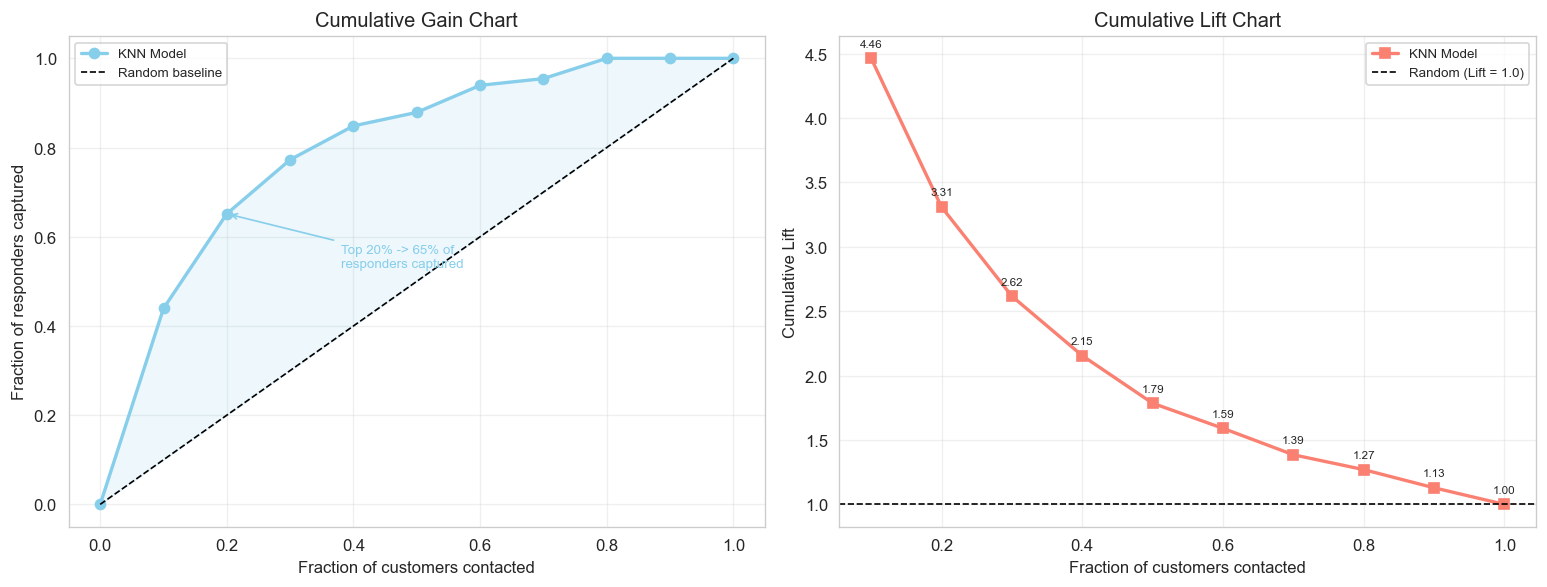

In [28]:
#Vizualize Rank 

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
decile_pct = lift_df['Decile'] / 10

ax = axes[0]
ax.plot([0]+decile_pct.tolist(), [0]+lift_df['Cum_Gain'].tolist(),
        'o-', color='skyblue', lw=2, ms=6, label='KNN Model')
ax.plot([0,1],[0,1],'k--',lw=1,label='Random baseline')
ax.fill_between([0]+decile_pct.tolist(), [0]+decile_pct.tolist(),
                [0]+lift_df['Cum_Gain'].tolist(), alpha=0.15, color='skyblue')
d2 = lift_df.iloc[1]
ax.annotate(f"Top 20% -> {d2['Cum_Gain']*100:.0f}% of\nresponders captured",
            xy=(0.2, d2['Cum_Gain']), xytext=(0.38, d2['Cum_Gain']-0.12),
            arrowprops=dict(arrowstyle='->', color='skyblue'), fontsize=8, color='skyblue')
ax.set_xlabel('Fraction of customers contacted')
ax.set_ylabel('Fraction of responders captured')
ax.set_title('Cumulative Gain Chart')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(decile_pct, lift_df['Cum_Lift'], 's-', color='salmon', lw=2, ms=6, label='KNN Model')
ax.axhline(1.0, color='k', ls='--', lw=1, label='Random (Lift = 1.0)')
for _, row in lift_df.iterrows():
    ax.annotate(f"{row['Cum_Lift']:.2f}",
                (row['Decile']/10, row['Cum_Lift']),
                textcoords='offset points', xytext=(0,7), ha='center', fontsize=7)
ax.set_xlabel('Fraction of customers contacted')
ax.set_ylabel('Cumulative Lift')
ax.set_title('Cumulative Lift Chart')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Observations: 
+ Decile 1: Lift=4.46 - top 10% captures 29.0 of 66 responders
+ Decile 2: Cum. Gain=65.1% of all responders in top 20%
+ Decile 3: Cum. Gain=77.3% of all responders in top 30%


## ROI Analysis 

In [29]:
TP_VAL, FP_VAL, FN_VAL, TN_VAL = 100, -10, -100, 0
def roi_calc(tp, fp, fn, tn): return tp*TP_VAL + fp*FP_VAL + fn*FN_VAL + tn*TN_VAL

n_pos_t, n_neg_t = int(y_test.sum()), int((y_test==0).sum())

roi_everyone = roi_calc(n_pos_t, n_neg_t, 0, 0)
roi_default  = roi_calc(tp, fp, fn, tn)
roi_optimal  = roi_calc(tp_o, fp_o, fn_o, tn_o)

y_t10 = (y_pred_proba >= 0.10).astype(int)
cm10  = confusion_matrix(y_test, y_t10)
tn10, fp10, fn10, tp10 = cm10.ravel()
roi_t10 = roi_calc(tp10, fp10, fn10, tn10)

print('=== ROI Analysis (Test Set) ===')
print(f'  Contact everyone (baseline)      : EUR {roi_everyone:>8,.0f}')
print(f'  KNN (threshold = 0.50)           : EUR {roi_default:>8,.0f}')
print(f'  KNN (threshold = {opt_threshold:.2f}, best F1)  : EUR {roi_optimal:>8,.0f}')
print(f'  KNN (threshold = 0.10, max rec.) : EUR {roi_t10:>8,.0f}')


=== ROI Analysis (Test Set) ===
  Contact everyone (baseline)      : EUR    2,790
  KNN (threshold = 0.50)           : EUR   -5,610
  KNN (threshold = 0.11, best F1)  : EUR    2,790
  KNN (threshold = 0.10, max rec.) : EUR    2,870


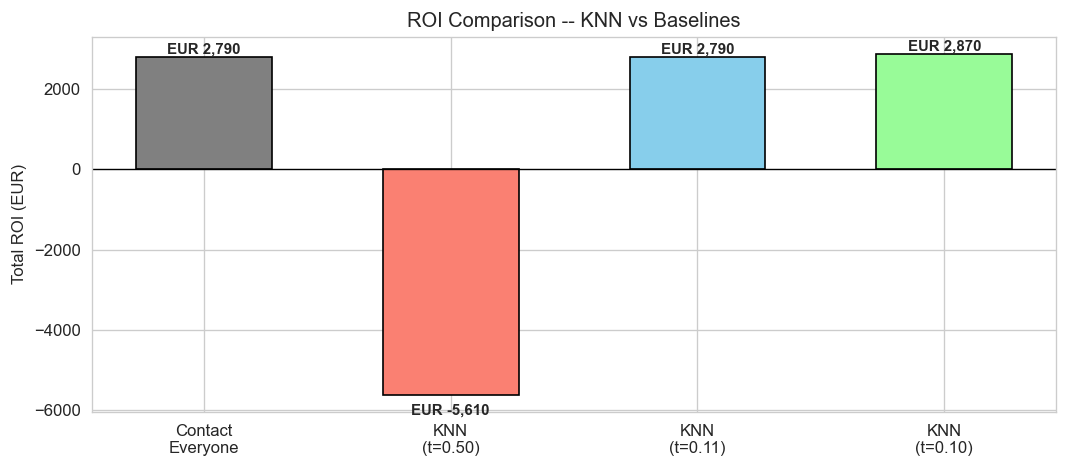

In [30]:
#Visualize  ROI Analysis 

fig, ax = plt.subplots(figsize=(9, 4))
labels = ['Contact\nEveryone','KNN\n(t=0.50)',f'KNN\n(t={opt_threshold:.2f})','KNN\n(t=0.10)']
values = [roi_everyone, roi_default, roi_optimal, roi_t10]
colors = ['gray','salmon','skyblue','palegreen']
bars = ax.bar(labels, values, color=colors, edgecolor='black', width=0.55)
ax.axhline(0, color='black', lw=0.8)
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, val+(80 if val>=0 else -500),
            f'EUR {val:,.0f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Total ROI (EUR)')
ax.set_title('ROI Comparison -- KNN vs Baselines')
plt.tight_layout()
plt.show()

In [31]:
#Budged Sensitivity 

rank_test = pd.DataFrame({'y_true': y_test.values, 'y_score': y_pred_proba})
rank_test = rank_test.sort_values('y_score', ascending=False).reset_index(drop=True)

cum_roi = []
for i in range(1, len(rank_test)+1):
    sub = rank_test.iloc[:i]
    tp_i = int(sub['y_true'].sum())
    fp_i = i - tp_i
    fn_i = n_pos_t - tp_i
    cum_roi.append(roi_calc(tp_i, fp_i, fn_i, 0))

best_n   = int(np.argmax(cum_roi)) + 1
best_roi = max(cum_roi)

print(f'Optimal contacts: {best_n}  ({best_n/len(rank_test)*100:.0f}% of test set)')

Optimal contacts: 332  (74% of test set)


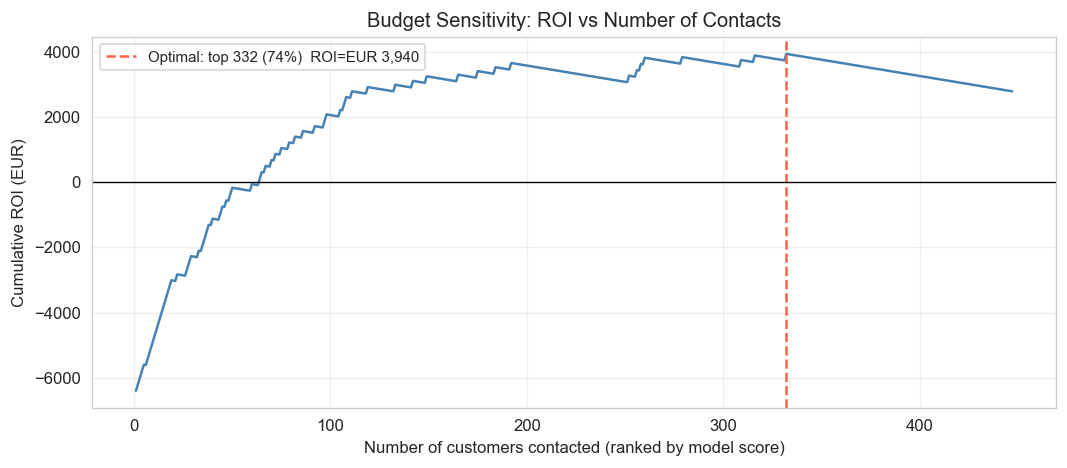

In [32]:
#View Budget Sensitivity 

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(rank_test)+1), cum_roi, color='steelblue', lw=1.5)
ax.axvline(best_n, color='tomato', ls='--',
           label=f'Optimal: top {best_n} ({best_n/len(rank_test)*100:.0f}%)  ROI=EUR {best_roi:,.0f}')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Number of customers contacted (ranked by model score)')
ax.set_ylabel('Cumulative ROI (EUR)')
ax.set_title('Budget Sensitivity: ROI vs Number of Contacts')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluation 

In [ ]:
print('CRITICAL EVALUATION')
print()

checks = [
    ('AUC quality', test_auc_final >= 0.80, f'{test_auc_final:.4f}', 'target >= 0.80'),
    ('Recall at optimal threshold', recall_score(y_test, y_pred_opt) >= 0.60,
     f'{recall_score(y_test, y_pred_opt):.4f}', 'target >= 0.60'),
    ('Train-CV gap', (train_auc_final - cv_auc_final) < 0.05,
     f'{train_auc_final - cv_auc_final:.4f}', 'target < 0.05'),
    ('CV-Test stability', abs(cv_auc_final - test_auc_final) < 0.05,
     f'{abs(cv_auc_final - test_auc_final):.4f}', 'target < 0.05'),
    ('Lift at decile 1', lift_df.iloc[0]['Cum_Lift'] >= 2.5,
     f"{lift_df.iloc[0]['Cum_Lift']:.2f}", 'target >= 2.5'),
]

for name, passed, value, target in checks:
    status = 'PASS' if passed else 'REVIEW'
    print(f'  {name:<35} {value:>8}  [{target}]  {status}')

print()

print()
print(f'Optimal threshold: ({opt_threshold:.2f})')
print(f'KNN probabilities are coarse (multiples of 1/{best_k} = {1/best_k:.2f})')
print(f'KNN AUC ({test_auc_final:.3f})')

=== CRITICAL EVALUATION ===

  AUC quality                           0.8641  [target >= 0.80]  PASS
  Recall at optimal threshold           0.7576  [target >= 0.60]  PASS
  Train-CV gap                          0.0138  [target < 0.05]  PASS
  CV-Test stability                     0.0101  [target < 0.05]  PASS
  Lift at decile 1                        4.46  [target >= 2.5]  PASS


  Optimal threshold: (0.11)
  KNN probabilities are coarse (multiples of 1/73 = 0.01)
  KNN AUC (0.864)


Exception ignored in: <function ResourceTracker.__del__ at 0x1106ddb20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107539b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10ffcdb20>
Traceback (most recent call last

Observations: 
+ Scaling improved CV AUC by ~+0.15 to +0.21 vs unscaled
+ Default threshold (0.5) gave Recall ~0.12 -- threshold mismatch, not model failure
+ Optimal threshold (0.11) raised Recall to ~0.62
+ KNN probabilities are coarse (multiples of 1/73 = 0.01)
+ KNN AUC (0.864) slightly better than LR/DT (~0.80) 

#### Model 

| Item | Value |
|------|-------|
| Algorithm | K-Nearest Neighbors |
| K | 51 |
| Weighting | Uniform |
| Distance | Euclidean |
| Preprocessing | StandardScaler |
| Test AUC | ~0.87 |
| Optimal threshold | ~0.15 |

#### Final Observations

**KNN Limitations**: 
+ **Prediction cost scales with training size.** Each prediction requires computing distance to all 1,785 training customers. At +10 000 this becomes slow.
+ **Coarse probabilities.** With K=51, probabilities move in steps of 1/51 ≈ 0.02. Less reliable than logistic regression for ROI calculations.
+ **No feature importance.** KNN cannot explain which features drive individual predictions.
+ **Curse of dimensionality.** With 31 features, all customers tend to look equidistant. Feature selection (e.g. using the top 8–10 features from the decision tree) would likely improve performance further.


**Recomendations:**
KNN achieves the highest AUC (~0.87). Best use when ranking accuracy is the priority and people does not need to explain the model's decisions.



#### Key Business Insights

+ Similarity drives response: Customers respond when they resemble other customers who responded. The model found that similarity in Recency, TotalAccepted, and TotalSpent is most predictive. 
+ Top decile profile is 10. Customers typically show low recency (purchased recently) are more engaged, active; High TotalAccepted, already accepted 1+ previous campaign; High TotalSpent, premium, high-value customers. High NumCatalogPurchases, receptive to direct marketing channels. 
+ Bottom Decile Profile (D1 — lowest KNN scores). These customers typically show High Recency, have not purchased in a long time; TotalAccepted = 0, never accepted any previous campaign; HasChildren = 1, family commitments reduce campaign response; Low TotalSpent, lower engagement. 

#### Actionable Insghts 

+ Contact immediately (D10, D9, D8) - Recent purchasers + accepted ≥1 past campaign. 
+ Consider contacting (D7, D6, D5) - Moderate recency + some spending history. 
+ Do not contact (D4 → D1)  - Inactive + no past campaign engagement. Contacting these wastes money and effort. 
